In [2]:
# ── 사용자 의도값 (데이터 무관) ──────────────────────────────
MORSE_NPZ          = 'output/prep_riem.npz'

COST_TARGET_RATIO  = 3000   # tube vs background cost 목표 대비
MIN_DIST_UM        = 25.0   # tip 간 최소 물리 거리 (µm)

# 고정 파라미터 (모델 파라미터, 데이터 무관)
GAMMA        = 0.95
SIGMA_PERP   = 1.0
MAX_TIPS     = 300
MIN_RADIUS_UM = 0.1
MERGE_DOT_MIN = 0.92

In [3]:
# ── Load ────────────────────────────────────────────────────
import numpy as np

d          = np.load(MORSE_NPZ)
T_down     = d['T_down'].astype(np.float32)
voxel_down = float(d['voxel_down'])
soma_r_um  = float(d['soma_r_um'])

print(f'T_down     : {T_down.shape}  voxel={voxel_down:.3f} µm')
print(f'T range    : {T_down.min():.4f} – {T_down.max():.4f}')
print(f'soma_r_um  : {soma_r_um:.2f} µm')

T_down     : (266, 249, 248)  voxel=1.368 µm
T range    : 0.0000 – 0.9758
soma_r_um  : 10.32 µm


T_down (foreground > 0.02) percentiles:
  p50: 0.0703
  p75: 0.1360
  p90: 0.2905
  p95: 0.4964
  p97: 0.5896
  p99: 0.6641

Otsu threshold: 0.2832
  below Otsu: 89.7%  above Otsu: 10.3%


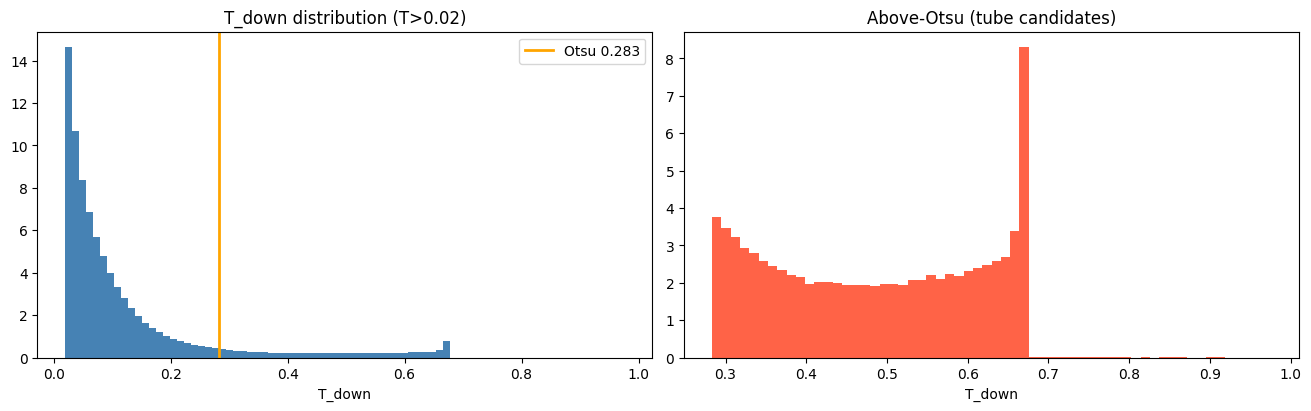

In [4]:
# ── T_down 분포 분석 ─────────────────────────────────────────
import matplotlib.pyplot as plt
from skimage.filters import threshold_otsu

T_fg = T_down[T_down > 0.02].ravel()

pcts = [50, 75, 90, 95, 97, 99]
print('T_down (foreground > 0.02) percentiles:')
for p in pcts:
    print(f'  p{p:2d}: {np.percentile(T_fg, p):.4f}')

otsu_val = threshold_otsu(T_fg)
print(f'\nOtsu threshold: {otsu_val:.4f}')
print(f'  below Otsu: {(T_fg < otsu_val).mean()*100:.1f}%  '
      f'above Otsu: {(T_fg >= otsu_val).mean()*100:.1f}%')

fig, axes = plt.subplots(1, 2, figsize=(13, 4), constrained_layout=True)
axes[0].hist(T_fg, bins=80, color='steelblue', density=True)
axes[0].axvline(otsu_val, color='orange', lw=2, label=f'Otsu {otsu_val:.3f}')
axes[0].set_xlabel('T_down'); axes[0].set_title('T_down distribution (T>0.02)')
axes[0].legend()

axes[1].hist(T_fg[T_fg >= otsu_val], bins=60, color='tomato', density=True)
axes[1].set_xlabel('T_down'); axes[1].set_title('Above-Otsu (tube candidates)')
plt.show()

In [5]:
# ── 파라미터 자동 감지 ────────────────────────────────────────

# MIN_T_TIP: Otsu threshold, clamp 0.20~0.60
MIN_T_TIP = float(threshold_otsu(T_fg))
MIN_T_TIP = round(float(np.clip(MIN_T_TIP, 0.20, 0.60)), 2)

# ALPHA: target cost ratio 기반
T_mean_tube = float(T_down[T_down > MIN_T_TIP * 0.5].mean())
ALPHA = float(np.log(COST_TARGET_RATIO) / T_mean_tube)
ALPHA = round(float(np.clip(ALPHA, 4.0, 16.0)), 1)

# MIN_DIST_VOX: 물리 거리 → voxel 수
MIN_DIST_VOX = int(round(MIN_DIST_UM / voxel_down))

# MIN_MEAN_T: tip threshold의 35%
MIN_MEAN_T = round(MIN_T_TIP * 0.35, 2)

# MIN_PATH_LEN_UM: soma 반경의 50% (최소 5 µm)
MIN_PATH_LEN_UM = round(float(max(5.0, soma_r_um * 0.5)), 1)

# MERGE_DIST_UM: soma 반경의 150% (최소 10 µm)
MERGE_DIST_UM = round(float(max(10.0, soma_r_um * 1.5)), 1)

# ── 감지 근거 출력 ────────────────────────────────────────────
print('=== 감지 근거 ===')
print(f'  MIN_T_TIP    : Otsu({otsu_val:.3f}) → clamp → {MIN_T_TIP}')
print(f'  ALPHA        : log({COST_TARGET_RATIO}) / T_mean_tube({T_mean_tube:.3f}) = {ALPHA}')
print(f'               : cost at T_mean = exp(-{ALPHA}×{T_mean_tube:.3f}) = {np.exp(-ALPHA*T_mean_tube):.5f}')
print(f'  MIN_DIST_VOX : {MIN_DIST_UM} µm / {voxel_down:.3f} µm/vox = {MIN_DIST_VOX} vox')
print(f'  MIN_MEAN_T   : {MIN_T_TIP} × 0.35 = {MIN_MEAN_T}')
print(f'  MIN_PATH_LEN : max(5.0, soma_r({soma_r_um:.1f})×0.5) = {MIN_PATH_LEN_UM} µm')
print(f'  MERGE_DIST   : max(10.0, soma_r({soma_r_um:.1f})×1.5) = {MERGE_DIST_UM} µm')

# ── step3 config 복붙용 출력 ─────────────────────────────────
print()
print('=' * 48)
print('  step3_aniso config 셀 복사용')
print('=' * 48)
print(f'ALPHA           = {ALPHA}')
print(f'SIGMA_PERP      = {SIGMA_PERP}')
print(f'GAMMA           = {GAMMA}')
print(f'MIN_DIST_VOX    = {MIN_DIST_VOX}')
print(f'MIN_T_TIP       = {MIN_T_TIP}')
print(f'MAX_TIPS        = {MAX_TIPS}')
print(f'MIN_PATH_LEN_UM = {MIN_PATH_LEN_UM}')
print(f'MIN_RADIUS_UM   = {MIN_RADIUS_UM}')
print(f'MIN_MEAN_T      = {MIN_MEAN_T}')
print(f'MERGE_DIST_UM   = {MERGE_DIST_UM}')
print(f'MERGE_DOT_MIN   = {MERGE_DOT_MIN}')
print('=' * 48)

=== 감지 근거 ===
  MIN_T_TIP    : Otsu(0.283) → clamp → 0.28
  ALPHA        : log(3000) / T_mean_tube(0.318) = 16.0
               : cost at T_mean = exp(-16.0×0.318) = 0.00619
  MIN_DIST_VOX : 25.0 µm / 1.368 µm/vox = 18 vox
  MIN_MEAN_T   : 0.28 × 0.35 = 0.1
  MIN_PATH_LEN : max(5.0, soma_r(10.3)×0.5) = 5.2 µm
  MERGE_DIST   : max(10.0, soma_r(10.3)×1.5) = 15.5 µm

  step3_aniso config 셀 복사용
ALPHA           = 16.0
SIGMA_PERP      = 1.0
GAMMA           = 0.95
MIN_DIST_VOX    = 18
MIN_T_TIP       = 0.28
MAX_TIPS        = 300
MIN_PATH_LEN_UM = 5.2
MIN_RADIUS_UM   = 0.1
MIN_MEAN_T      = 0.1
MERGE_DIST_UM   = 15.5
MERGE_DOT_MIN   = 0.92
